In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import random

seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)



In [3]:


#Basic Transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
    ])

#Download Dataset
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

#Create DataLoaders
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)



In [4]:
class LargeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Making it "Larger" (Wider)
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1) 
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
        self.conv4 = nn.Conv2d(256, 512, 3, padding=1)
        
        self.fc1 = nn.Linear(512 * 2 * 2, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        # Using ReLU to ensure the model is powerful enough to overfit
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv4(x))
        x = F.max_pool2d(x, 2)
        
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [5]:

# 6. Initialize Network
model = LargeCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


In [6]:
# 7. Training Function
def train(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    gradient_norms = {}

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        # Save gradient norms
        for name, param in model.named_parameters():

            if param.grad is not None:

                grad_norm = param.grad.norm().item()

                if name not in gradient_norms:
                    gradient_norms[name] = []

                gradient_norms[name].append(grad_norm)

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total
    train_f1 = f1_score(all_labels, all_preds, average='macro')

    avg_loss = running_loss / len(loader)

    return avg_loss, accuracy, train_f1, gradient_norms


In [7]:
# 8. Testing Function
def test(model, loader):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total
    test_f1 = f1_score(all_labels, all_preds, average='macro')

    avg_loss = running_loss / len(loader)

    return avg_loss, accuracy, test_f1


In [8]:
num_epochs = 50 # Increase significantly to create overfitting [cite: 2203]

train_losses, test_losses = [], []
train_accs, test_accs = [], []
train_f1s, test_f1s = [], []
all_epoch_gradient_norms = []

for epoch in range(num_epochs):
    # 1. Run training and testing
    train_loss, train_acc, train_f1, grad_norms = train(model, train_loader)
    test_loss, test_acc, test_f1 = test(model, test_loader)

    # 2. Extract and Store (This fulfills your Task 3 instruction)
    train_losses.append(train_loss)
    test_losses.append(test_loss) # This is your "Validation Loss"
    train_accs.append(train_acc)
    test_accs.append(test_acc) # This is your "Validation Accuracy"
    train_f1s.append(train_f1)
    test_f1s.append(test_f1)

    # 3. Process Gradients (Optional for Task 3, but good for consistency)
    epoch_grad_averages = {layer: sum(norms)/len(norms) for layer, norms in grad_norms.items()}
    all_epoch_gradient_norms.append(epoch_grad_averages)

    # 4. MONITORING
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Validation Loss: {test_loss:.4f}")
    print(f"Train Acc: {train_acc:.2f}% | Validation Acc: {test_acc:.2f}%")
    print(f"Train F1: {train_f1:.4f} | Validation F1: {test_f1:.4f}")
    print("-" * 40)


Epoch 1/50
Train Loss: 1.4626 | Validation Loss: 1.0928
Train Acc: 46.12% | Validation Acc: 61.00%
Train F1: 0.4555 | Validation F1: 0.6094
----------------------------------------
Epoch 2/50
Train Loss: 0.9511 | Validation Loss: 0.8882
Train Acc: 66.24% | Validation Acc: 68.47%
Train F1: 0.6608 | Validation F1: 0.6747
----------------------------------------
Epoch 3/50
Train Loss: 0.7157 | Validation Loss: 0.7274
Train Acc: 74.91% | Validation Acc: 74.55%
Train F1: 0.7484 | Validation F1: 0.7463
----------------------------------------
Epoch 4/50
Train Loss: 0.5530 | Validation Loss: 0.6985
Train Acc: 80.44% | Validation Acc: 76.03%
Train F1: 0.8040 | Validation F1: 0.7591
----------------------------------------
Epoch 5/50
Train Loss: 0.4145 | Validation Loss: 0.7929
Train Acc: 85.39% | Validation Acc: 75.27%
Train F1: 0.8537 | Validation F1: 0.7502
----------------------------------------
Epoch 6/50
Train Loss: 0.2938 | Validation Loss: 0.7279
Train Acc: 89.68% | Validation Acc: 77.

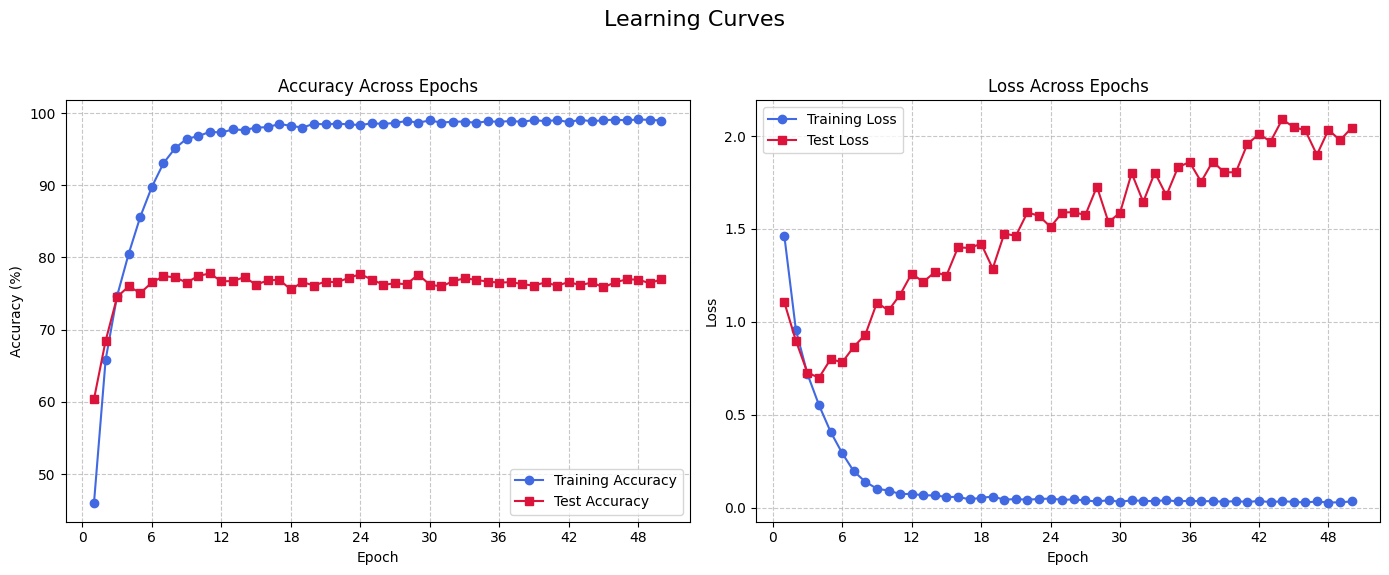

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Define the epoch range (1 to num_epochs)
epochs = range(1, num_epochs + 1)

# Create the main figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('Learning Curves', fontsize=16) # Set the name of the whole figure

# --- Plot 1: Accuracy ---
ax1.plot(epochs, train_accs, marker='o', label='Training Accuracy', color='royalblue')
ax1.plot(epochs, test_accs, marker='s', label='Test Accuracy', color='crimson')
ax1.set_title('Accuracy Across Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=10))
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: Loss ---
ax2.plot(epochs, train_losses, marker='o', label='Training Loss', color='royalblue')
ax2.plot(epochs, test_losses, marker='s', label='Test Loss', color='crimson')
ax2.set_title('Loss Across Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=10))
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

# --- Plot 3: F1 Score ---
ax3.plot(epochs, train_f1s, marker='o', label='Training F1', color='royalblue')
ax3.plot(epochs, test_f1s, marker='s', label='Test F1', color='crimson')
ax3.set_title('F1 Score Across Epochs')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Macro F1 Score')
ax3.xaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=10))
ax3.set_ylim(0, 1)
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()


In [ ]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Significantly reduced filters compared to the "Large" model
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1) 
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv4 = nn.Conv2d(64, 128, 3, padding=1)
        
        # Smaller hidden layer
        self.fc1 = nn.Linear(128 * 2 * 2, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv4(x))
        x = F.max_pool2d(x, 2)
        
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
# --- 1. Settings for Smaller Model Solution ---
num_epochs = 50 
model = SmallCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Storage for plots (Required for Task 3)
train_losses, test_losses = [], []
train_accs, test_accs = [], []

print("Starting Task 3: Smaller Model Strategy...")

for epoch in range(num_epochs):
    # 2. Standard train/test steps
    train_loss, train_acc, _ = train(model, train_loader)
    val_loss, val_acc = test(model, test_loader)

    # 3. Store metrics
    train_losses.append(train_loss)
    test_losses.append(val_loss)
    train_accs.append(train_acc)
    test_accs.append(val_acc)

    # 4. Monitoring
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Validation Loss: {val_loss:.4f}")
    print(f"Train Acc: {train_acc:.2f}% | Validation Acc: {val_acc:.2f}%")
    print("-" * 40)